In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
allocation_df = pd.read_csv("../../data/processed/week3_allocation_df.csv", index_col=0, parse_dates=True)
sector_returns = pd.read_csv("../../data/processed/week2_returns_clean.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("../../data/processed/week2_prices_clean.csv", index_col=0, parse_dates=True)

In [3]:
print("allocation_df shape:", allocation_df.shape)
print("sector_returns shape:", sector_returns.shape)
print("prices shape:", prices.shape)

allocation_df shape: (79, 11)
sector_returns shape: (1644, 12)
prices shape: (1645, 12)


In [4]:
allocation_df.head()

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2018-06-30,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-07-31,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-08-31,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-09-30,0.0,0.0,0.0,0.0,0.333333,0.333333,0.000000,0.000000,0.000000,0.333333,0.0
2018-10-31,0.0,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.333333,0.333333,0.000000,0.0


In [5]:
sector_returns.head()

,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2018-06-20,0.001706,-0.003248,0.012410,0.004415,-0.002559,0.000683,0.002100,0.000980,0.010794,0.000797,0.002121,0.004741
2018-06-21,-0.006269,-0.010635,-0.006129,-0.018516,-0.002933,-0.012555,-0.007683,0.001956,0.005967,0.003385,-0.005762,-0.007123
2018-06-22,0.001824,0.014563,0.004376,0.019951,-0.004780,0.003455,-0.003239,0.008202,0.008742,0.006944,0.004494,-0.001704
2018-06-25,-0.013613,-0.015550,-0.020598,-0.020093,-0.010713,-0.012670,-0.020762,0.005036,-0.002476,0.016551,-0.009184,-0.021739
2018-06-26,0.002214,0.003819,0.001658,0.012629,-0.003361,0.003766,0.004039,-0.004240,0.005275,0.001164,-0.003090,0.007162


In [6]:
spy_returns = sector_returns["SPY"]
sector_returns_only = sector_returns.drop(columns=["SPY"])


In [7]:
print("allocation_df shape:", allocation_df.shape)
print("sector_returns_only shape:", sector_returns_only.shape)
print("spy_returns shape:", spy_returns.shape)

allocation_df shape: (79, 11)
sector_returns_only shape: (1644, 11)
spy_returns shape: (1644,)


In [8]:
daily_weights = allocation_df.reindex(sector_returns_only.index, method="ffill")
daily_weights.head()

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2018-06-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
daily_weights.loc["2018-09-25":"2018-10-05"]

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2018-09-25,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-26,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-27,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-28,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-10-01,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-02,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-03,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-04,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-05,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0


In [10]:
daily_weights_shifted = daily_weights.shift(1)
daily_weights_shifted.loc["2018-09-25":"2018-10-05"]

,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2018-09-25,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-26,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-27,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-09-28,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-10-01,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
2018-10-02,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-03,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-04,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0
2018-10-05,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.333333,0.0


In [11]:
strategy_daily_returns = (daily_weights_shifted * sector_returns_only).sum(axis=1)
strategy_daily_returns.head(10)

Date
2018-06-20    0.0
2018-06-21    0.0
2018-06-22    0.0
2018-06-25    0.0
2018-06-26    0.0
2018-06-27    0.0
2018-06-28    0.0
2018-06-29    0.0
2018-07-02    0.0
2018-07-03    0.0
dtype: float64

In [12]:
initial_value = 100000
portfolio_value = initial_value * (1 + strategy_daily_returns).cumprod()
portfolio_value.head(10)

Date
2018-06-20    100000.0
2018-06-21    100000.0
2018-06-22    100000.0
2018-06-25    100000.0
2018-06-26    100000.0
2018-06-27    100000.0
2018-06-28    100000.0
2018-06-29    100000.0
2018-07-02    100000.0
2018-07-03    100000.0
dtype: float64

In [13]:
strategy_daily_returns.loc["2018-10-01":"2018-10-10"]

Date
2018-10-01    0.000000
2018-10-02    0.000419
2018-10-03    0.001772
2018-10-04   -0.010355
2018-10-05   -0.006313
2018-10-08   -0.003055
2018-10-09   -0.003383
2018-10-10   -0.034766
dtype: float64

In [14]:
portfolio_value.loc["2018-10-01":"2018-10-10"]

Date
2018-10-01    100000.000000
2018-10-02    100041.924245
2018-10-03    100219.226538
2018-10-04     99181.442082
2018-10-05     98555.287680
2018-10-08     98254.200771
2018-10-09     97921.846541
2018-10-10     94517.528004
dtype: float64

In [15]:
cumulative_return = portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1
print("Cumulative Return:", cumulative_return)

Cumulative Return: 0.37077806967473714


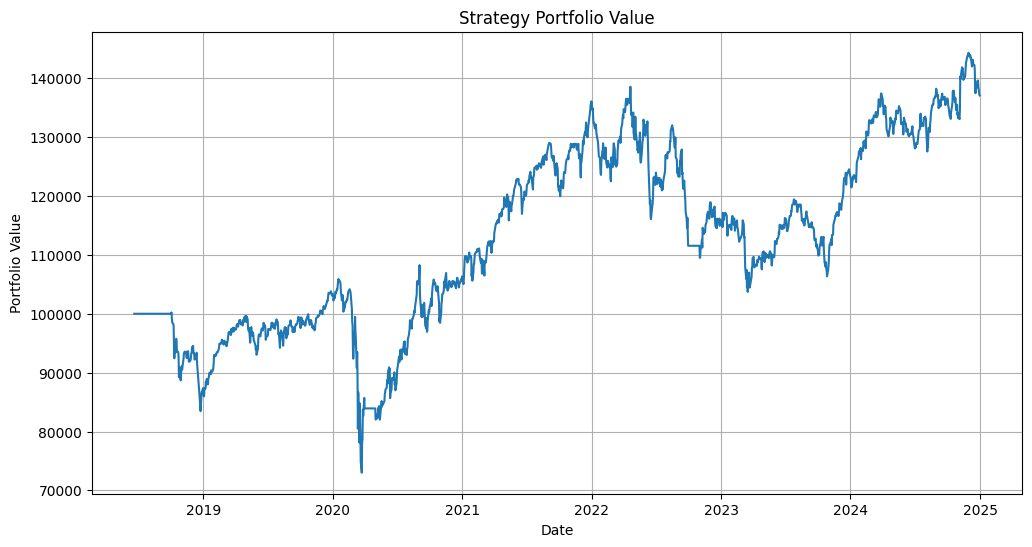

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value.values)
plt.title("Strategy Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

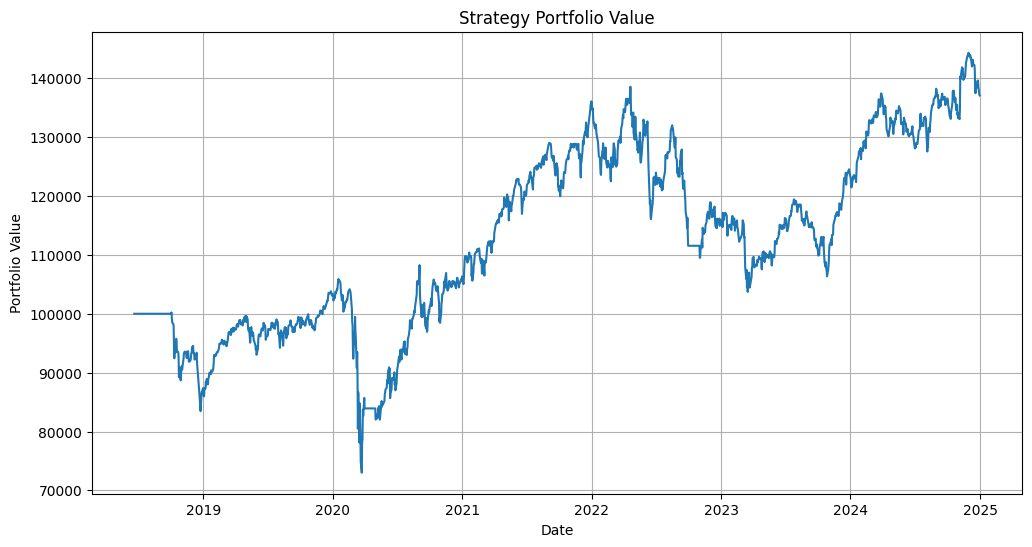

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value.values)
plt.title("Strategy Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

In [18]:
annual_volatility = strategy_daily_returns.std() * np.sqrt(252)
print("Annualized Volatility:", annual_volatility)

Annualized Volatility: 0.16810764741330175


In [19]:
rolling_max = portfolio_value.cummax()
drawdown_series = (portfolio_value - rolling_max) / rolling_max
max_drawdown = drawdown_series.min()

print("Maximum Drawdown:", max_drawdown)


Maximum Drawdown: -0.31071709213843207


In [20]:
sharpe_ratio = (strategy_daily_returns.mean() / strategy_daily_returns.std()) * np.sqrt(252)
print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.37202763577823666


In [21]:
years = len(portfolio_value) / 252
cagr = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (1 / years) - 1
print("CAGR:", cagr)

CAGR: 0.04953025904142816


In [22]:
spy_portfolio_value = 100000 * (1 + spy_returns).cumprod()
spy_portfolio_value.head()

Date
2018-06-20    100170.626328
2018-06-21     99542.623356
2018-06-22     99724.143912
2018-06-25     98366.589536
2018-06-26     98584.392988
Name: SPY, dtype: float64

In [23]:
equal_weight_returns = sector_returns_only.mean(axis=1)
equal_weight_portfolio_value = 100000 * (1 + equal_weight_returns).cumprod()
equal_weight_portfolio_value.head()

Date
2018-06-20    100302.118174
2018-06-21     99754.768738
2018-06-22    100308.007100
2018-06-25     99284.882575
2018-06-26     99545.009324
dtype: float64

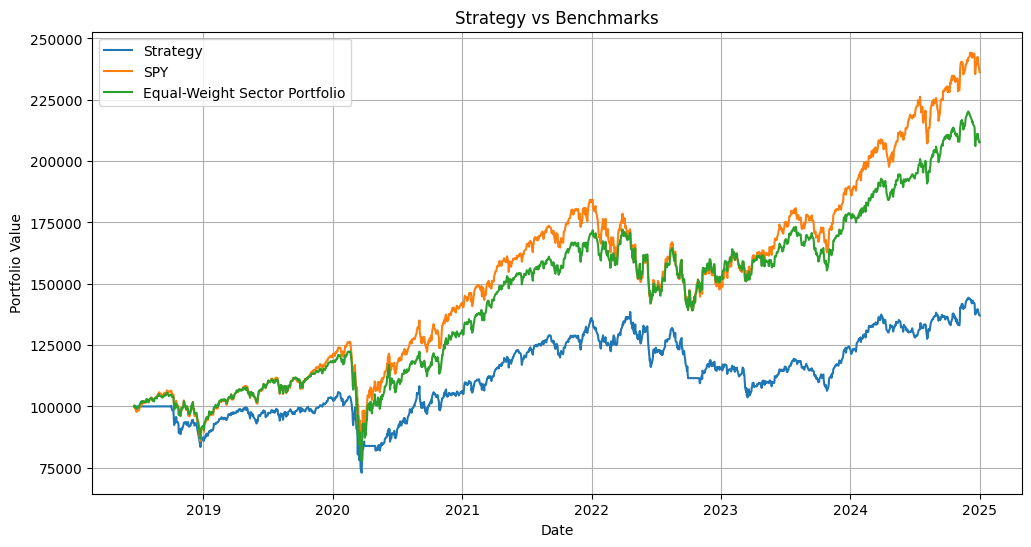

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value.values, label="Strategy")
plt.plot(spy_portfolio_value.index, spy_portfolio_value.values, label="SPY")
plt.plot(equal_weight_portfolio_value.index, equal_weight_portfolio_value.values, label="Equal-Weight Sector Portfolio")

plt.title("Strategy vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
strategy_cum_return = portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1
spy_cum_return = spy_portfolio_value.iloc[-1] / spy_portfolio_value.iloc[0] - 1
equal_weight_cum_return = equal_weight_portfolio_value.iloc[-1] / equal_weight_portfolio_value.iloc[0] - 1

print("Strategy Cumulative Return:", strategy_cum_return)
print("SPY Cumulative Return:", spy_cum_return)
print("Equal-Weight Sector Portfolio Cumulative Return:", equal_weight_cum_return)

Strategy Cumulative Return: 0.37077806967473714
SPY Cumulative Return: 1.358272402684475
Equal-Weight Sector Portfolio Cumulative Return: 1.0711028797312454


In [26]:
summary_df = pd.DataFrame({
    "Portfolio": ["Strategy", "SPY", "Equal-Weight Sector Portfolio"],
    "Cumulative Return": [strategy_cum_return, spy_cum_return, equal_weight_cum_return]
})

summary_df

,Portfolio,Cumulative Return
0,Strategy,0.370778
1,SPY,1.358272
2,Equal-Weight Sector Portfolio,1.071103
